# Polynomial fit for the cross-section of electron-H atom elastic collisions

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import k, e, pi, m_e, m_p, epsilon_0

%config InlineBackend.figure_format = 'svg'

## Hydrogen

fit parameters 

p[0] = 2.594073e-03
p[1] = -1.722430e-02
p[2] = -9.759949e-02
p[3] = -3.205016e-01
p[4] = -4.289062e+01


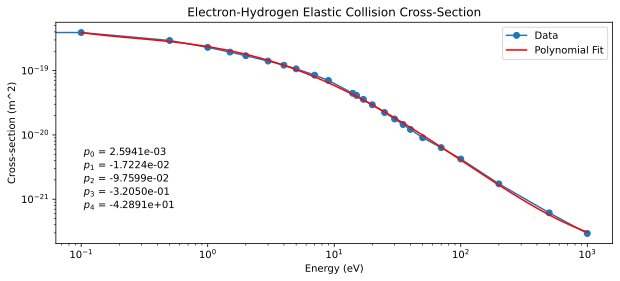

In [40]:
# - Morgan database, www.lxcat.net, retrieved on May 3, 2025.
# SPECIES: e / H
# PROCESS: E + H -> E + H, Elastic
# PARAM.:  m/M = 0.000548193, complete set
# UPDATED: 2010-07-16 14:34:41


# Log data
data = np.loadtxt( './H_cross_section.txt', skiprows=2)
E_eV = data[:,0]
sigma_m2 = data[:,1]

# Perform a polynomial fit of the log-transformed data
log_E_eV = np.log(E_eV[1:])
log_sigma_m2 = np.log(sigma_m2[1:])

# Fit a polynomial of degree 4
p = np.polyfit(log_E_eV, log_sigma_m2, 4)

def sigma_eh( E_eV ):
    """
    Calculate the cross-section for electron-H atom elastic collisions

    Parameters
    ----------
    E_eV : float
    """
    log_E_eV = np.log(E_eV)
    log_sigma_m2 = p[4] + p[3]*log_E_eV + p[2]*log_E_eV**2 + p[1]*log_E_eV**3 + p[0]*log_E_eV**4
    sigma_m2 = np.exp(log_sigma_m2)
    return sigma_m2

plt.figure(figsize=(10,4))
# Plot the cross-section
plt.loglog(data[:,0], data[:,1], '-o')
# Plot the polynomial fit
E_eV = np.logspace(np.log10(E_eV[1]), np.log10(E_eV[-1]), 100)
sigma_m2 = sigma_eh(E_eV)
plt.loglog(E_eV, sigma_m2, '-r')

plt.xlabel('Energy (eV)')
plt.ylabel('Cross-section (m^2)')
plt.title('Electron-Hydrogen Elastic Collision Cross-Section')
print('fit parameters \n')
for i, coeff in enumerate(p):
    print(f'p[{i}] = {coeff:.6e}')

for _ in range(len(p)):
    plt.text(0.05, 0.4 - 0.06*_, rf'$p_{{{_}}}$ = {p[_]:.4e}', transform=plt.gca().transAxes)
plt.legend(['Data', 'Polynomial Fit'], loc='best')
plt.savefig('hydrogen_elastic_collision_cross_section.png', dpi=400)

# Nitrogen

fit parameters 

p[0] = 1.037399e-03
p[1] = -9.214733e-03
p[2] = 2.022475e-02
p[3] = -8.564895e-03
p[4] = 5.504094e-03
p[5] = -1.908797e-01
p[6] = -4.340419e+01


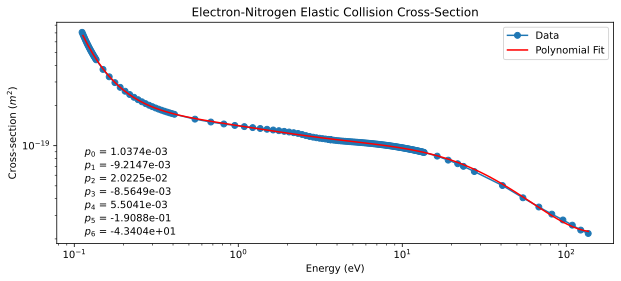

In [41]:
# - Morgan database, www.lxcat.net, retrieved on May 3, 2025.
# SPECIES: e / H
# PROCESS: E + H -> E + H, Elastic
# PARAM.:  m/M = 0.000548193, complete set
# UPDATED: 2010-07-16 14:34:41


# Log data
data = np.loadtxt( './N_cross_section.txt', skiprows=2)
E_eV = data[:,0]
sigma_m2 = data[:,1]

# Perform a polynomial fit of the log-transformed data
log_E_eV = np.log(E_eV[1:])
log_sigma_m2 = np.log(sigma_m2[1:])

# Fit a polynomial of degree 4
p = np.polyfit(log_E_eV, log_sigma_m2, 6)

def sigma_eh( E_eV ):
    """
    Calculate the cross-section for electron-H atom elastic collisions

    Parameters
    ----------
    E_eV : float
    """
    log_E_eV = np.log(E_eV)
    log_sigma_m2 = p[6] + p[5]*log_E_eV + p[4]*log_E_eV**2 + p[3]*log_E_eV**3 + p[2]*log_E_eV**4 + p[1]*log_E_eV**5 + p[0]*log_E_eV**6
    sigma_m2 = np.exp(log_sigma_m2)
    return sigma_m2

plt.figure(figsize=(10,4))
# Plot the cross-section
plt.loglog(data[:,0], data[:,1], '-o')
# Plot the polynomial fit
E_eV = np.logspace(np.log10(E_eV[1]), np.log10(E_eV[-1]), 100)
sigma_m2 = sigma_eh(E_eV)
plt.loglog(E_eV, sigma_m2, '-r')

plt.xlabel('Energy (eV)')
plt.ylabel(r'Cross-section ($m^2$)')
plt.title('Electron-Nitrogen Elastic Collision Cross-Section')
print('fit parameters \n')
for i, coeff in enumerate(p):
    print(f'p[{i}] = {coeff:.6e}')

for _ in range(len(p)):
    plt.text(0.05, 0.4 - 0.06*_, rf'$p_{{{_}}}$ = {p[_]:.4e}', transform=plt.gca().transAxes)
plt.legend(['Data', 'Polynomial Fit'], loc='best')
plt.savefig('nitrogen_elastic_collision_cross_section.png', dpi=400)

# Evaluate collision frequencies

In [6]:
def nu_eh( n_h, T_e ):
    """
    Calculate the collision frequency for electron-H atom elastic collisions
    using Eq. (A5) from https://arxiv.org/pdf/2305.16779

    Parameters
    ----------
    n_e : float
        Electron number density (m^-3)
    T_e : float
        Electron temperature (K)

    Returns
    -------
    nu_eH : float
        Collision frequency for electron-H atom elastic collisions (s^-1)
    """
    # Calculate mean energy
    E_bar = 4/np.pi * k * T_e

    # Calculate reduced mass
    mu = m_e * m_p / (m_e + m_p)

    # Find corresponding cross-section
    sigma = sigma_eh(E_bar/e) # Convert E_bar to eV

    # Calculate collision frequency
    nu_eh = n_h * 4/3 * np.sqrt(2*E_bar/mu) * sigma
    return nu_eh


In [7]:
def nu_ei( n_e, T_e, T_h ):
    """
    Calculate the collision frequency for electron-ion collisions
    using Eq. (A1) from https://arxiv.org/pdf/2305.16779

    Parameters
    ----------
    n_e : float
        Electron number density (m^-3)
    T_e : float
        Electron temperature (K)

    Returns
    -------
    nu_ei : float
        Collision frequency for electron-ion collisions (s^-1)
    """
    # Calculate the Coulomb logarithm
    Lambda_ei = np.log( 3/(2*np.sqrt(np.pi)) * np.sqrt(
        (4*pi*epsilon_0*k*T_e)**3 / (e**6 * n_e * (1+T_e/T_h))
    ))

    # Apply lower limit
    Lambda_ei = np.maximum(Lambda_ei, 0.5*np.log(2) )

    # Calculate the collision frequency
    nu_ei = 4/3 * np.sqrt(2*np.pi/m_e) * n_e * e**4 * Lambda_ei / (
        (4*pi*epsilon_0)**2 * (k*T_e)**(3/2)
    )
    return nu_ei


Text(0, 0.5, 'Collision frequency (s$^{-1}$)')

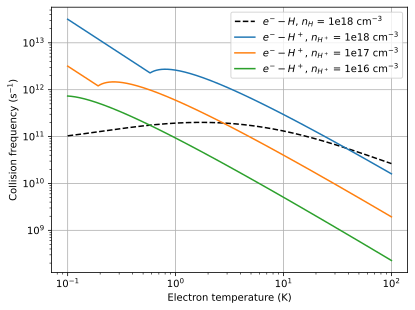

In [8]:
T_e_eV = np.logspace(-1, 2, 1000)
T_e = T_e_eV * e/k
T_h = 300
n_h = 1e24 # m^-3
nu_h = nu_eh(n_h, T_e)

plt.figure()
plt.grid()

plt.loglog(T_e_eV, nu_h, 'k--', label='$e^{-}-H$, $n_{H}$ = 1e18 cm$^{-3}$')
plt.loglog(T_e_eV, nu_ei(1e24, T_e, T_h), '-', label='$e^{-}-H^+$, $n_{H^+}$ = 1e18 cm$^{-3}$')
plt.loglog(T_e_eV, nu_ei(1e23, T_e, T_h), '-', label='$e^{-}-H^+$, $n_{H^+}$ = 1e17 cm$^{-3}$')
plt.loglog(T_e_eV, nu_ei(1e22, T_e, T_h), '-', label='$e^{-}-H^+$, $n_{H^+}$ = 1e16 cm$^{-3}$')
plt.legend()
plt.xlabel('Electron temperature (K)')
plt.ylabel(r'Collision frequency (s$^{-1}$)')